# Init-Scale Policy Smoke Test

This notebook runs a paired smoke test to compare two initialization scaling policies for modular RNNs:

- `full`: scale all trainable parameters in `network.community`
- `exclude_readout`: scale trainable parameters except `network.community.readout.*`

It visualizes training trajectories, transfer proxy, and representation dimensionality.

In [14]:
from __future__ import annotations

import copy
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.decomposition import PCA

from a1b2.data.basic_funcs import set_seed
from a1b2.analysis import transfer_interference as ann
from a1b2.training.simulation import run_simulation
from a1b2.models.two_module_rnn import TwoModuleRNNWrapper
from a1b2.models.rnn_init import _iter_scaled_parameters

sns.set_theme(style="whitegrid")

ROOT = Path.cwd().resolve().parent
DATA_FOLDER = ROOT / "data"
CONFIG_PATH = ROOT / "a1b2" / "models" / "experiments.json"
SMOKE_ROOT = DATA_FOLDER / "simulations" / "smoke_init_scale_policy"
SMOKE_ROOT.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r") as f:
    SETTINGS = json.load(f)

DF = ann.load_participant_data(str(DATA_FOLDER))
TASK_PARAMETERS = ann.setup_task_parameters()
DIM_INPUT = TASK_PARAMETERS["nStim_perTask"] * 2
DIM_OUTPUT = 4
print("Loaded participants:", DF["participant"].nunique())

Loaded participants: 305


In [15]:
def get_condition(condition_name: str) -> dict:
    c = next((x for x in SETTINGS["conditions"] if x["name"] == condition_name), None)
    if c is None:
        raise ValueError(f"Condition not found: {condition_name}")
    return copy.deepcopy(c)


def n_pcs_95(hiddens: np.ndarray) -> float:
    X = np.asarray(hiddens)
    if X.size == 0:
        return np.nan
    if X.ndim > 2:
        X = X.reshape(X.shape[0], -1)
    if X.shape[0] < 2 or X.shape[1] < 2:
        return np.nan
    pca = PCA().fit(X)
    csum = np.cumsum(pca.explained_variance_ratio_)
    return float(np.searchsorted(csum, 0.95) + 1)


def summarize_results(results: list[dict], condition_name: str, policy: str, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    traj_rows, transfer_rows, rep_rows = [], [], []

    for res in results:
        participant = str(res["participant"])
        acc = np.asarray(res.get("accuracy"))
        losses = np.asarray(res.get("losses"))

        # Transfer proxy
        if acc.ndim == 2 and acc.shape[0] >= 2:
            final_A1 = float(np.mean(acc[0, -6:]))
            initial_B = float(np.mean(acc[1, :6]))
            transfer_rows.append({
                "condition_name": condition_name,
                "policy": policy,
                "seed": seed,
                "participant": participant,
                "final_A1_acc": final_A1,
                "initial_B_acc": initial_B,
                "error_diff": initial_B - final_A1,
            })

        # Trajectories
        phase_names = ["post_A", "post_B", "post_A2"]
        for phase_idx, phase_name in enumerate(phase_names):
            if acc.ndim == 2 and phase_idx < acc.shape[0]:
                for step, v in enumerate(acc[phase_idx]):
                    traj_rows.append({
                        "condition_name": condition_name,
                        "policy": policy,
                        "seed": seed,
                        "participant": participant,
                        "phase": phase_name,
                        "step": int(step),
                        "metric": "accuracy",
                        "value": float(v),
                    })
            if losses.ndim == 2 and phase_idx < losses.shape[0]:
                for step, v in enumerate(losses[phase_idx]):
                    traj_rows.append({
                        "condition_name": condition_name,
                        "policy": policy,
                        "seed": seed,
                        "participant": participant,
                        "phase": phase_name,
                        "step": int(step),
                        "metric": "loss",
                        "value": float(v),
                    })

            key = f"hiddens_post_phase_{phase_idx}"
            if key in res:
                rep_rows.append({
                    "condition_name": condition_name,
                    "policy": policy,
                    "seed": seed,
                    "participant": participant,
                    "phase": phase_name,
                    "n_pcs_95": n_pcs_95(res[key]),
                })

    return pd.DataFrame(traj_rows), pd.DataFrame(transfer_rows), pd.DataFrame(rep_rows)


In [16]:
# Moderate runtime defaults (adjust as needed)
BASE_CONDITIONS = [
    # shared
    "two_module_rnn_25_nb2_init0.7",
    "two_module_rnn_25_low_sparse_nb2_init0.7",
    "two_module_rnn_25_no_comms_nb2_init0.7",
    # task_routed
    "two_module_rnn_25_task_routed_nb2_init0.7",
    "two_module_rnn_25_task_routed_low_sparse_nb2_init0.7",
    "two_module_rnn_25_task_routed_no_comms_nb2_init0.7",
]
POLICIES = ["full", "exclude_readout"]
SEEDS = [2024, 2025]
N_PARTICIPANTS = 3
N_EPOCHS = 10

# Stratified participant selection to guarantee same/near/far coverage.
part_by_cond = {}
for cond in ["same", "near", "far"]:
    mask = DF["participant"].astype(str).str.contains(f"_{cond}_")
    part_by_cond[cond] = sorted(DF.loc[mask, "participant"].astype(str).unique().tolist())

n_per_cond = max(1, N_PARTICIPANTS // 3)
participants = []
for cond in ["same", "near", "far"]:
    participants.extend(part_by_cond[cond][:n_per_cond])

# Fill remainder (if any) from pooled participants while keeping uniqueness.
if len(participants) < N_PARTICIPANTS:
    pooled = sorted(DF["participant"].astype(str).unique().tolist())
    for p in pooled:
        if p not in participants:
            participants.append(p)
        if len(participants) >= N_PARTICIPANTS:
            break

print("Participants subset:", len(participants))
print("Participants by inferred schedule:")
for cond in ["same", "near", "far"]:
    print(f"  {cond}: {sum(f'_{cond}_' in p for p in participants)}")

all_traj, all_transfer, all_rep = [], [], []

tasks = [(base_name, policy, seed) for base_name in BASE_CONDITIONS for policy in POLICIES for seed in SEEDS]

pbar = tqdm(tasks, total=len(tasks), desc="Smoke runs")
for base_name, policy, seed in pbar:
    pbar.set_postfix_str(f"{base_name} | {policy} | seed={seed}")

    base_condition = get_condition(base_name)
    set_seed(seed)
    condition = copy.deepcopy(base_condition)
    condition["init_scale_policy"] = policy

    # Training params mirror scripts/02_run_simulations.py shape
    n_train_trials = N_EPOCHS * (TASK_PARAMETERS["nStim_perTask"] * 2) * 10
    training_params = [
        participants,
        SETTINGS["n_phase"],
        N_EPOCHS,
        n_train_trials,
        SETTINGS["shuffle"],
        SETTINGS["batch_size"],
        condition.get("gamma", 0.01),
        SETTINGS["learning_rate"],
    ]

    n_modules = condition.get("n_modules", 2 if condition.get("arch") == "two_module_rnn" else 1)
    network_params = [DIM_INPUT, n_modules * condition.get("dim_hidden", 25), DIM_OUTPUT]

    run_tag = f"{base_name}__policy-{policy}__seed-{seed}"
    run_folder = SMOKE_ROOT / run_tag
    run_folder.mkdir(parents=True, exist_ok=True)

    out = run_simulation(
        training_params=training_params,
        network_params=network_params,
        task_parameters=TASK_PARAMETERS,
        df=DF,
        do_test=1,
        dosave=1,
        sim_folder=str(run_folder),
        arch=condition.get("arch", "ffn"),
        condition=condition,
    )

    traj_df, transfer_df, rep_df = summarize_results(
        out, condition_name=base_name, policy=policy, seed=seed
    )
    all_traj.append(traj_df)
    all_transfer.append(transfer_df)
    all_rep.append(rep_df)

traj_df = pd.concat(all_traj, ignore_index=True) if all_traj else pd.DataFrame()
transfer_df = pd.concat(all_transfer, ignore_index=True) if all_transfer else pd.DataFrame()
rep_df = pd.concat(all_rep, ignore_index=True) if all_rep else pd.DataFrame()

print("traj_df:", traj_df.shape)
print("transfer_df:", transfer_df.shape)
print("rep_df:", rep_df.shape)
display(transfer_df.head(), rep_df.head())

Participants subset: 3
Participants by inferred schedule:
  same: 1
  near: 1
  far: 1


Smoke runs: 100%|██████████| 24/24 [13:16<00:00, 33.19s/it, two_module_rnn_25_task_routed_no_comms_nb2_init0.7 | exclude_readout | seed=2025]

traj_df: (518400, 8)
transfer_df: (72, 7)
rep_df: (216, 6)


,condition_name,policy,seed,participant,final_A1_acc,initial_B_acc,error_diff
0,two_module_rnn_25_nb2_init0.7,full,2024,study1_same_sub1,0.960814,0.497827,-0.462987
1,two_module_rnn_25_nb2_init0.7,full,2024,study1_near_sub1,0.981542,0.470592,-0.510949
2,two_module_rnn_25_nb2_init0.7,full,2024,study1_far_sub1,0.982505,0.469171,-0.513333
3,two_module_rnn_25_nb2_init0.7,full,2025,study1_same_sub1,0.971247,0.778959,-0.192288
4,two_module_rnn_25_nb2_init0.7,full,2025,study1_near_sub1,0.994072,0.246146,-0.747926


,condition_name,policy,seed,participant,phase,n_pcs_95
0,two_module_rnn_25_nb2_init0.7,full,2024,study1_same_sub1,post_A,8.0
1,two_module_rnn_25_nb2_init0.7,full,2024,study1_same_sub1,post_B,7.0
2,two_module_rnn_25_nb2_init0.7,full,2024,study1_same_sub1,post_A2,7.0
3,two_module_rnn_25_nb2_init0.7,full,2024,study1_near_sub1,post_A,9.0
4,two_module_rnn_25_nb2_init0.7,full,2024,study1_near_sub1,post_B,8.0


In [17]:
display(transfer_df, rep_df)

,condition_name,policy,seed,participant,final_A1_acc,initial_B_acc,error_diff
0,two_module_rnn_25_nb2_init0.7,full,2024,study1_same_sub1,0.960814,0.497827,-0.462987
1,two_module_rnn_25_nb2_init0.7,full,2024,study1_near_sub1,0.981542,0.470592,-0.510949
2,two_module_rnn_25_nb2_init0.7,full,2024,study1_far_sub1,0.982505,0.469171,-0.513333
3,two_module_rnn_25_nb2_init0.7,full,2025,study1_same_sub1,0.971247,0.778959,-0.192288
4,two_module_rnn_25_nb2_init0.7,full,2025,study1_near_sub1,0.994072,0.246146,-0.747926
...,...,...,...,...,...,...,...
67,two_module_rnn_25_task_routed_no_comms_nb2_ini...,exclude_readout,2024,study1_near_sub1,0.847763,0.438012,-0.409751
68,two_module_rnn_25_task_routed_no_comms_nb2_ini...,exclude_readout,2024,study1_far_sub1,0.868027,0.389800,-0.478227
69,two_module_rnn_25_task_routed_no_comms_nb2_ini...,exclude_readout,2025,study1_same_sub1,0.835872,0.622405,-0.213467
70,two_module_rnn_25_task_routed_no_comms_nb2_ini...,exclude_readout,2025,study1_near_sub1,0.834954,0.328700,-0.506254


,condition_name,policy,seed,participant,phase,n_pcs_95
0,two_module_rnn_25_nb2_init0.7,full,2024,study1_same_sub1,post_A,8.0
1,two_module_rnn_25_nb2_init0.7,full,2024,study1_same_sub1,post_B,7.0
2,two_module_rnn_25_nb2_init0.7,full,2024,study1_same_sub1,post_A2,7.0
3,two_module_rnn_25_nb2_init0.7,full,2024,study1_near_sub1,post_A,9.0
4,two_module_rnn_25_nb2_init0.7,full,2024,study1_near_sub1,post_B,8.0
...,...,...,...,...,...,...
211,two_module_rnn_25_task_routed_no_comms_nb2_ini...,exclude_readout,2025,study1_near_sub1,post_B,7.0
212,two_module_rnn_25_task_routed_no_comms_nb2_ini...,exclude_readout,2025,study1_near_sub1,post_A2,8.0
213,two_module_rnn_25_task_routed_no_comms_nb2_ini...,exclude_readout,2025,study1_far_sub1,post_A,8.0
214,two_module_rnn_25_task_routed_no_comms_nb2_ini...,exclude_readout,2025,study1_far_sub1,post_B,7.0


In [18]:
# Sanity-check: which parameters are scaled under each policy?
probe_condition = get_condition(BASE_CONDITIONS[0])
probe_model = TwoModuleRNNWrapper(
    input_size=DIM_INPUT,
    output_size=DIM_OUTPUT,
    hidden_size=probe_condition.get("dim_hidden", 25),
    n_modules=probe_condition.get("n_modules", 2),
    sparsity=probe_condition.get("sparsity", 1.0),
    common_input=probe_condition.get("common_input", False),
    common_readout=probe_condition.get("common_readout", True),
    cell_type=probe_condition.get("cell_type", "RNN"),
    input_routing=probe_condition.get("input_routing", "shared"),
)

for pol in POLICIES:
    names = [n for n, _ in _iter_scaled_parameters(probe_model, pol)]
    print(f"policy={pol}: n_scaled={len(names)}")
    print("  sample:", names[:8])
    print("  includes_readout:", any(n.startswith("readout.") for n in names))


policy=full: n_scaled=6
  sample: ['core.parametrizations.weight_ih_l0.original', 'core.parametrizations.weight_hh_l0.original', 'comms.parametrizations.weight_ih_l0.original', 'comms.parametrizations.weight_hh_l0.original', 'readout.layers.bias', 'readout.layers.parametrizations.weight.original']
  includes_readout: True
policy=exclude_readout: n_scaled=4
  sample: ['core.parametrizations.weight_ih_l0.original', 'core.parametrizations.weight_hh_l0.original', 'comms.parametrizations.weight_ih_l0.original', 'comms.parametrizations.weight_hh_l0.original']
  includes_readout: False


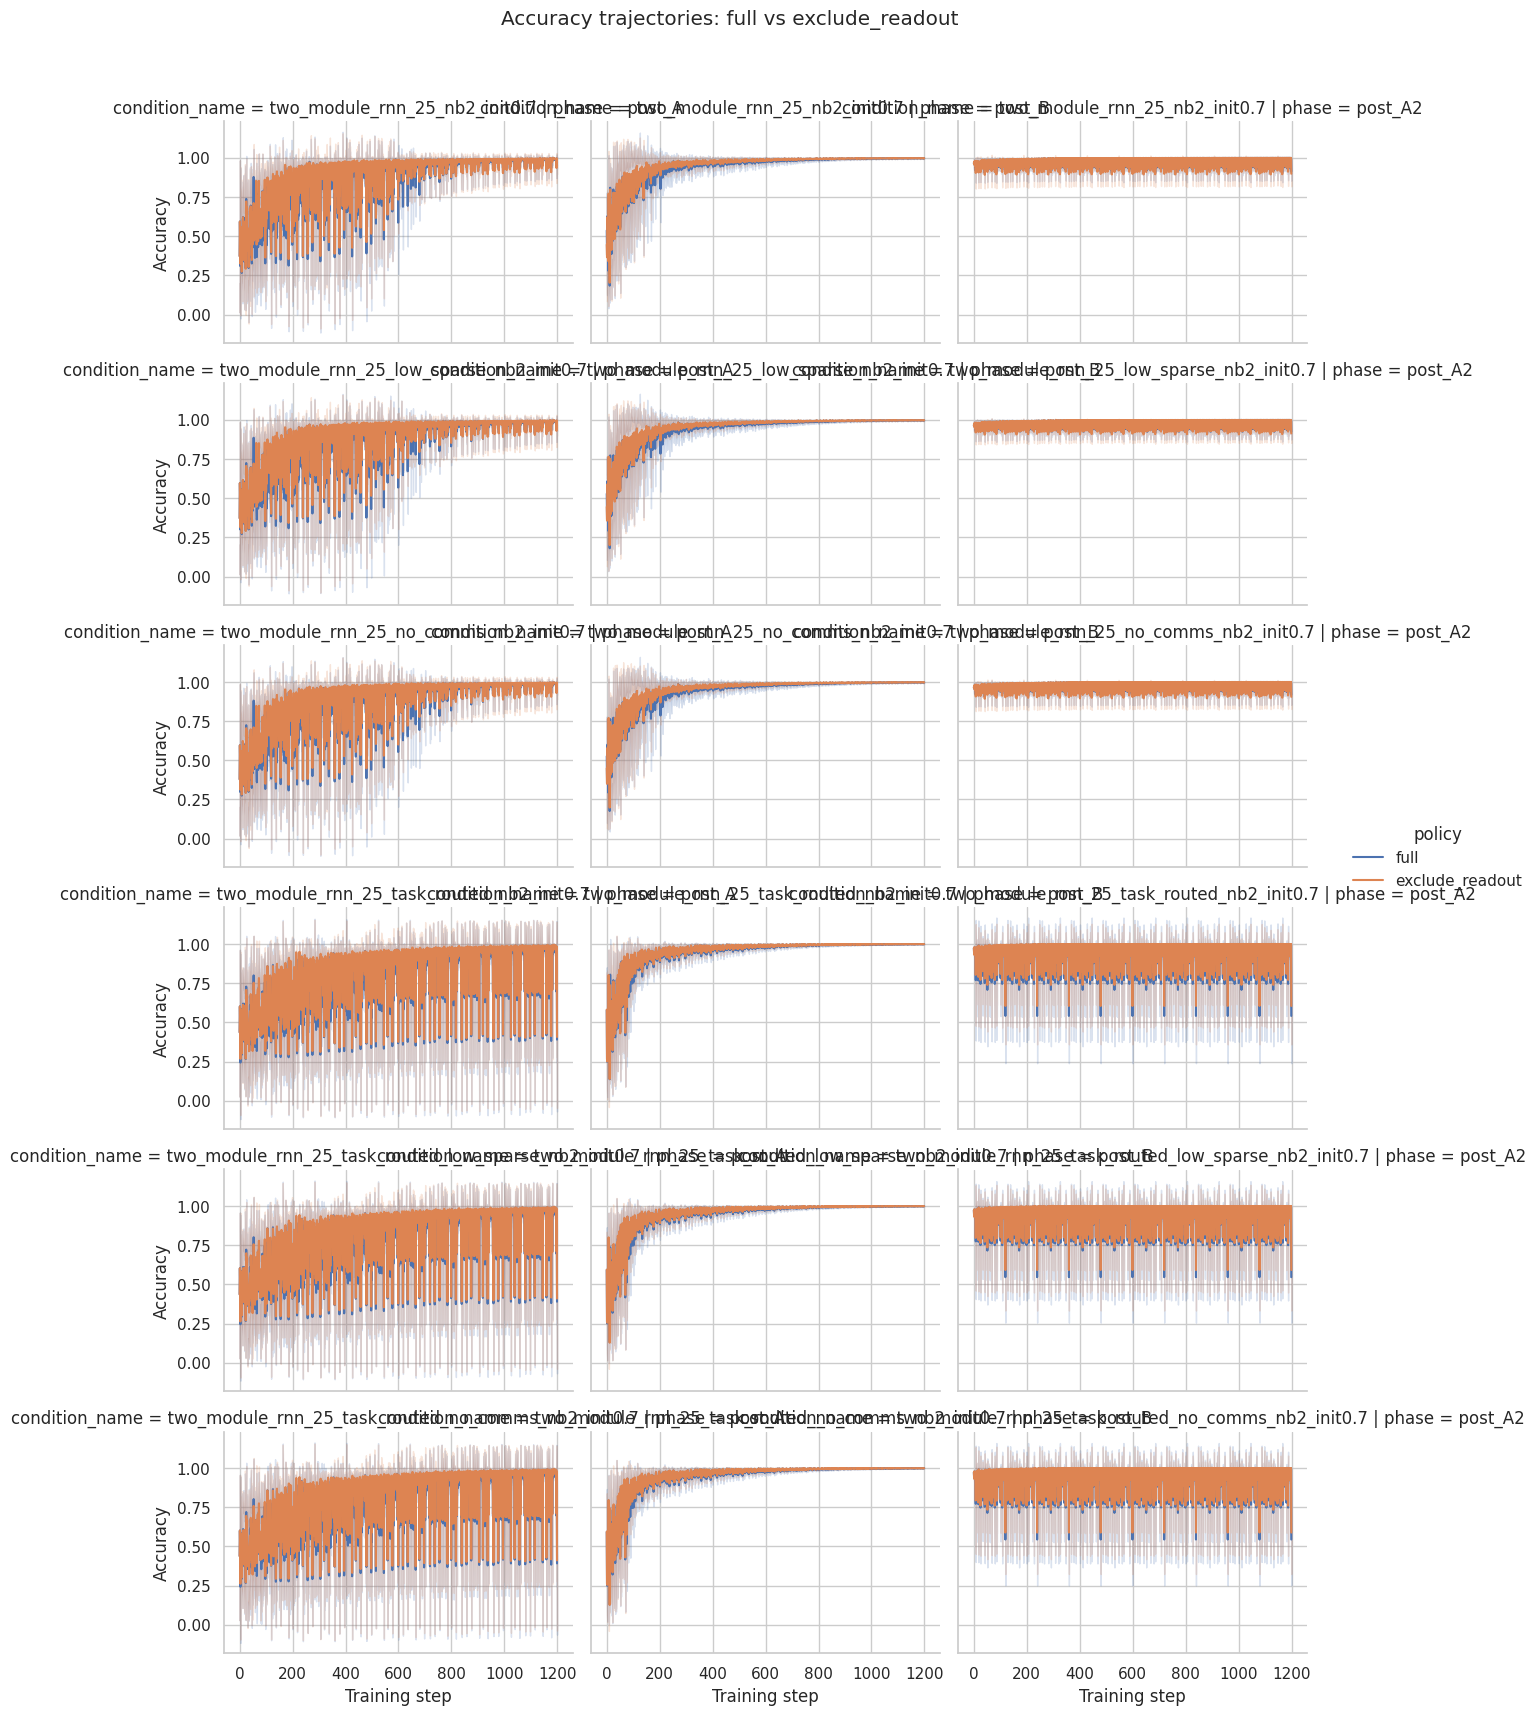

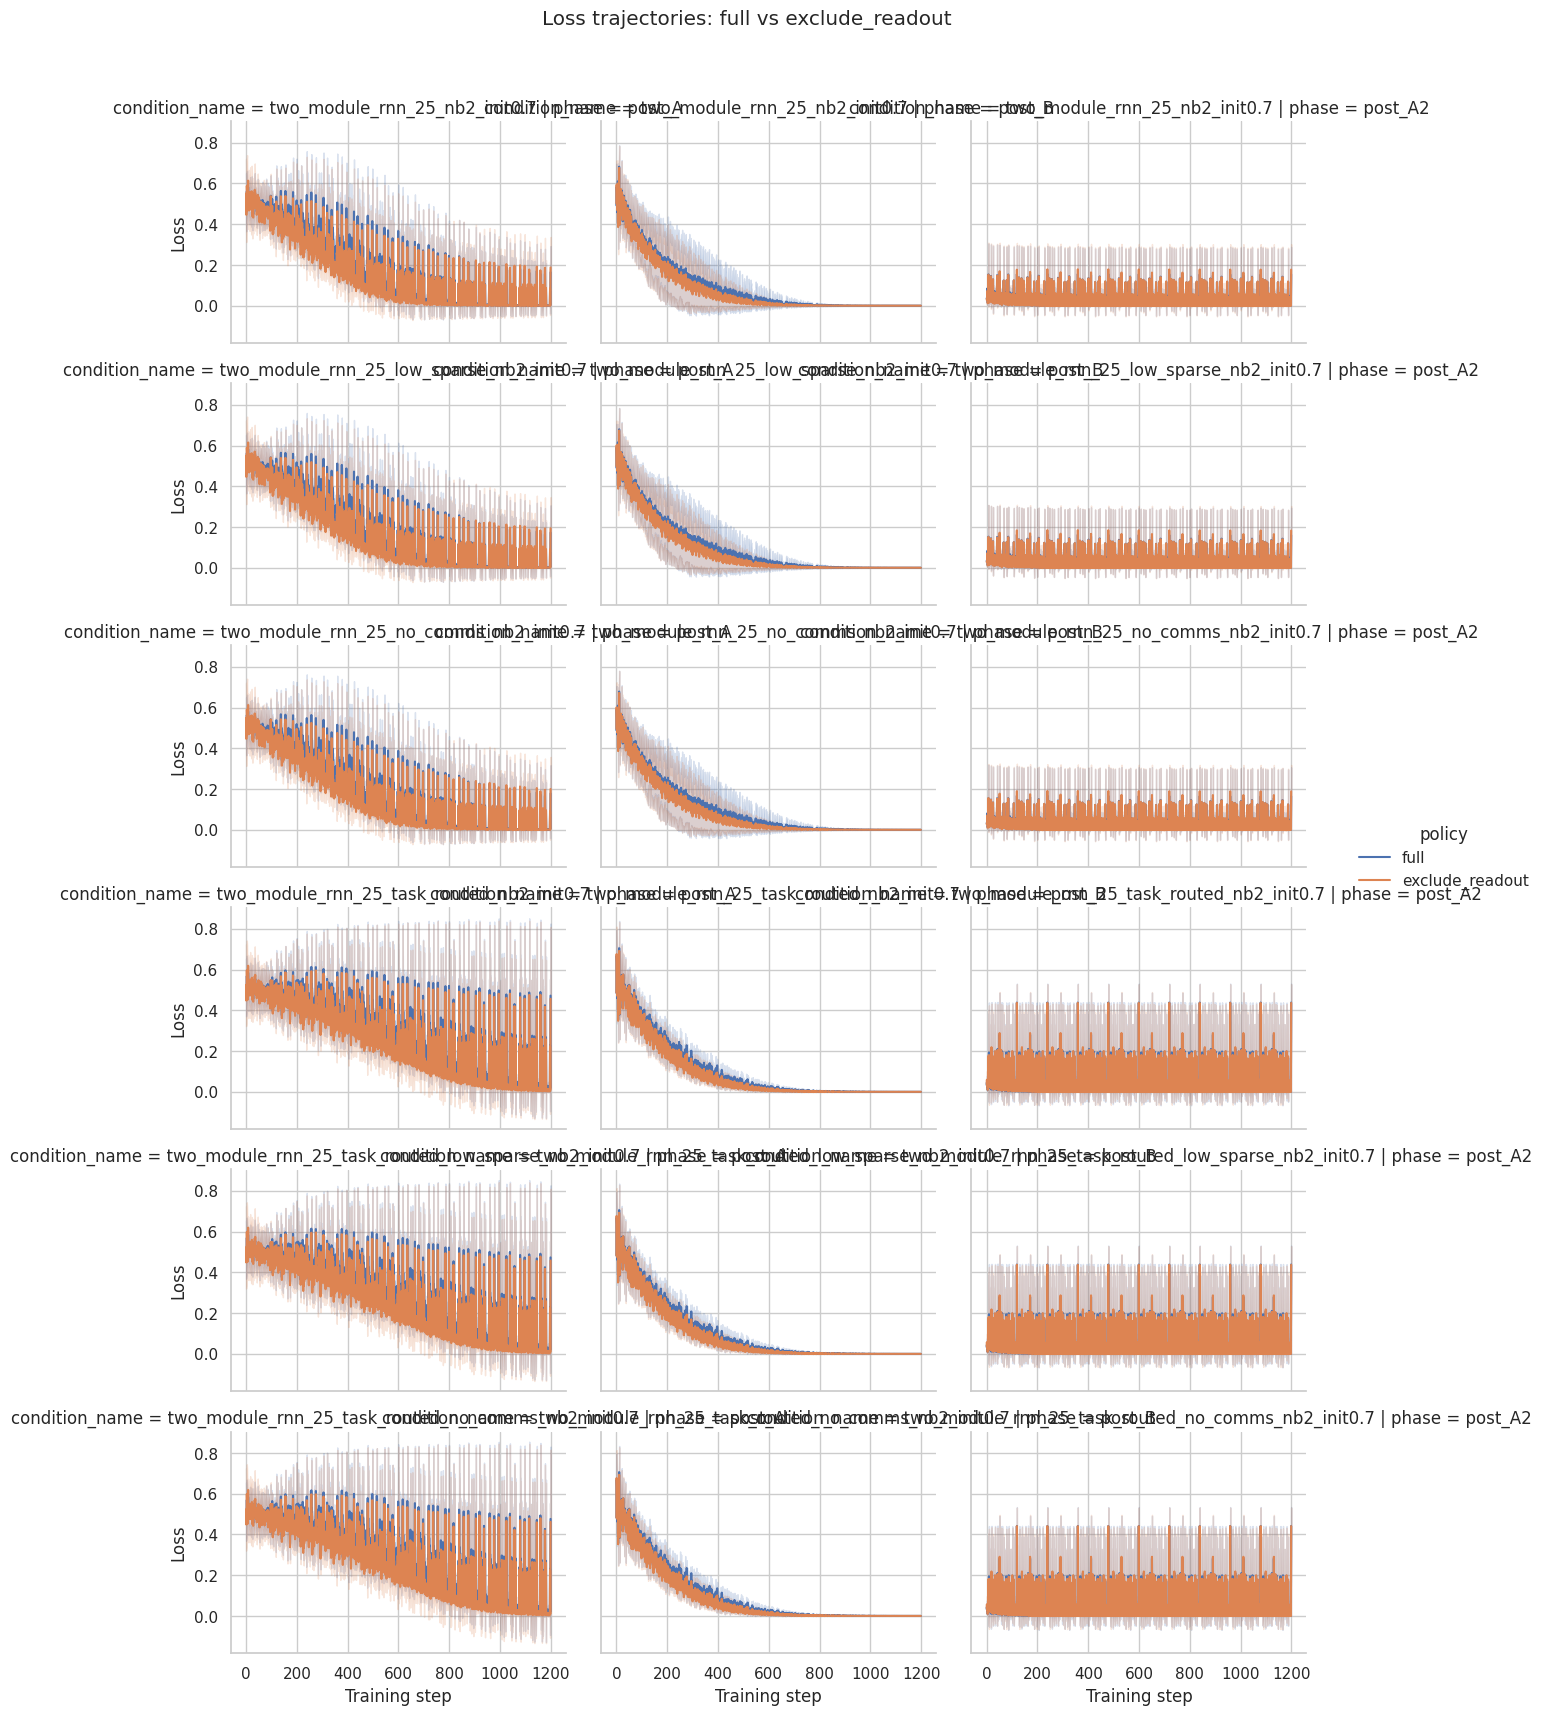

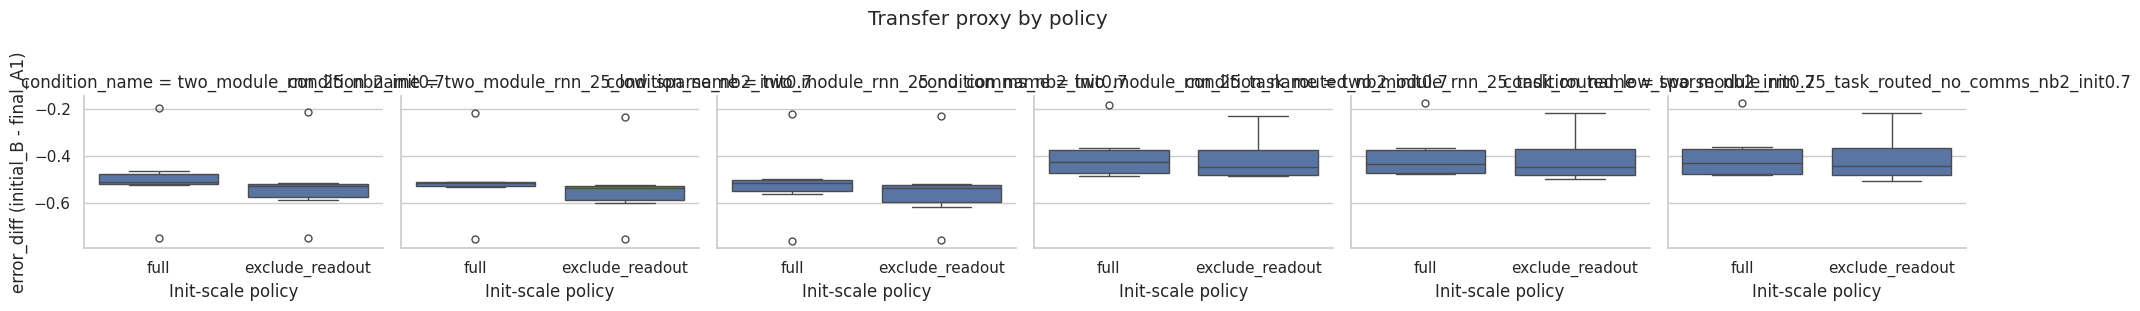

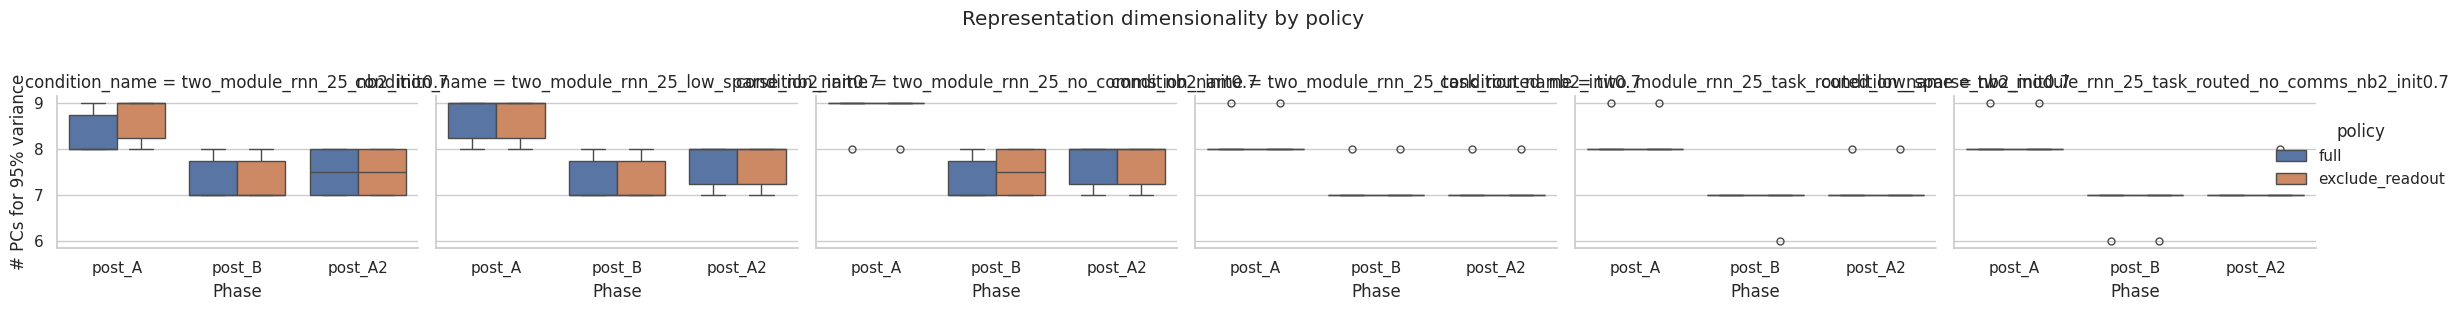

In [19]:
# Visuals: trajectories, transfer proxy, representation dimensionality
if not traj_df.empty:
    for metric in ["accuracy", "loss"]:
        sub = traj_df[traj_df["metric"] == metric].copy()
        g = sns.relplot(
            data=sub,
            x="step",
            y="value",
            hue="policy",
            col="phase",
            row="condition_name",
            kind="line",
            estimator="mean",
            errorbar="sd",
            height=2.8,
            aspect=1.2,
        )
        g.set_axis_labels("Training step", metric.title())
        g.fig.suptitle(f"{metric.title()} trajectories: full vs exclude_readout", y=1.02)
        plt.tight_layout()
        plt.show()

if not transfer_df.empty:
    g = sns.catplot(
        data=transfer_df,
        x="policy",
        y="error_diff",
        col="condition_name",
        kind="box",
        height=3.0,
        aspect=1.1,
    )
    g.set_axis_labels("Init-scale policy", "error_diff (initial_B - final_A1)")
    g.fig.suptitle("Transfer proxy by policy", y=1.03)
    plt.tight_layout()
    plt.show()

if not rep_df.empty:
    g = sns.catplot(
        data=rep_df,
        x="phase",
        y="n_pcs_95",
        hue="policy",
        col="condition_name",
        kind="box",
        height=3.0,
        aspect=1.2,
    )
    g.set_axis_labels("Phase", "# PCs for 95% variance")
    g.fig.suptitle("Representation dimensionality by policy", y=1.03)
    plt.tight_layout()
    plt.show()

Geometry runs: 24


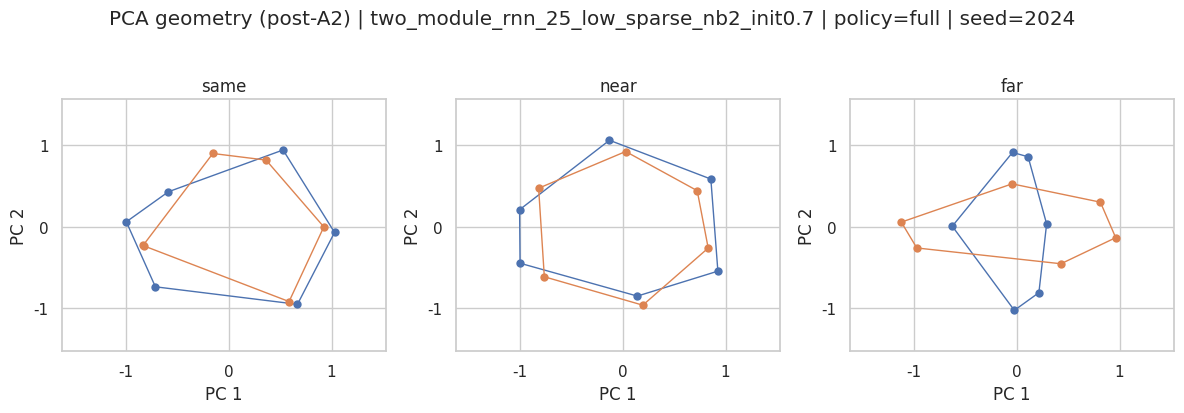

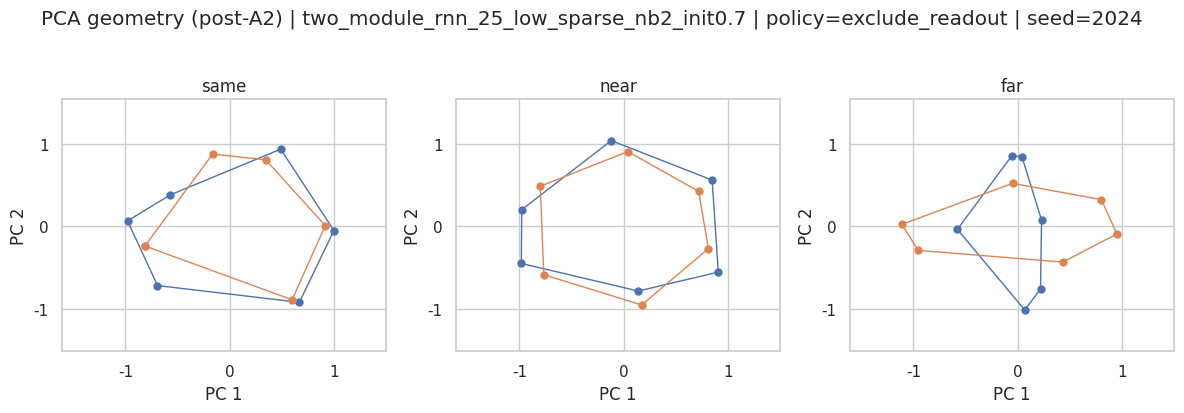

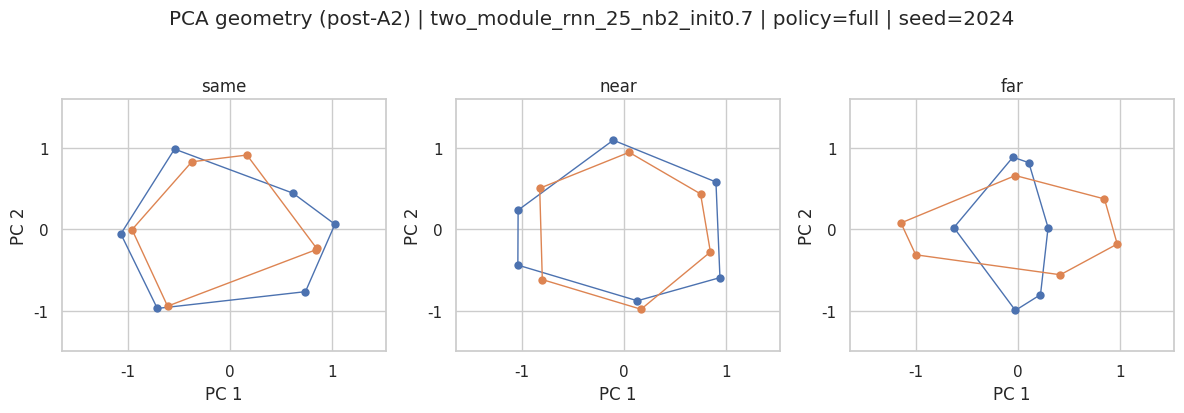

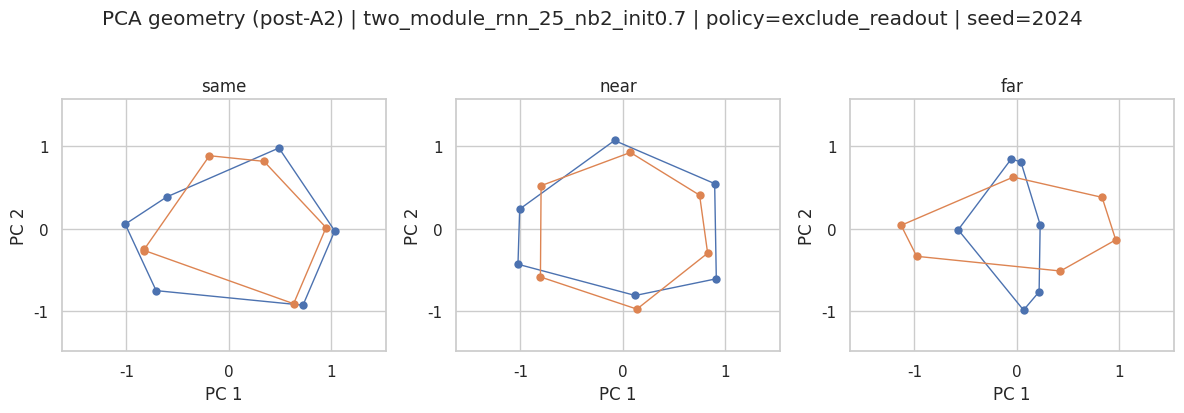

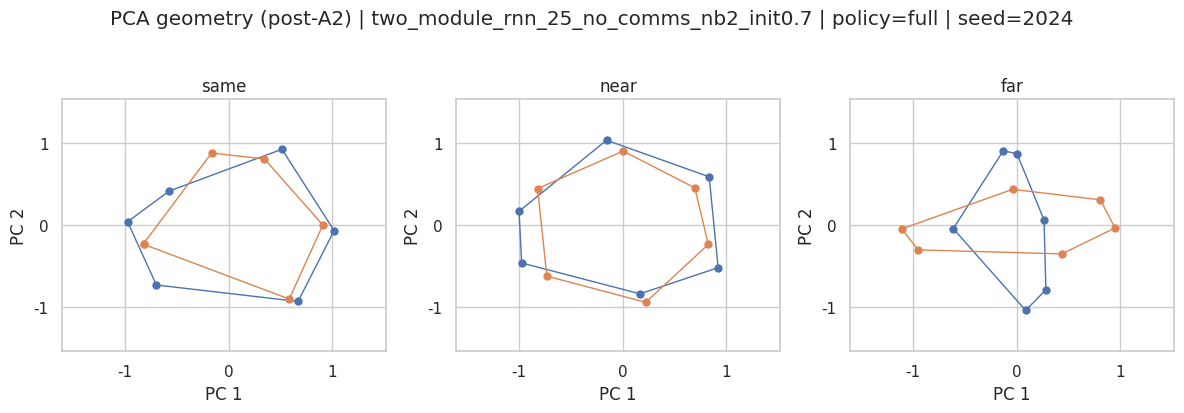

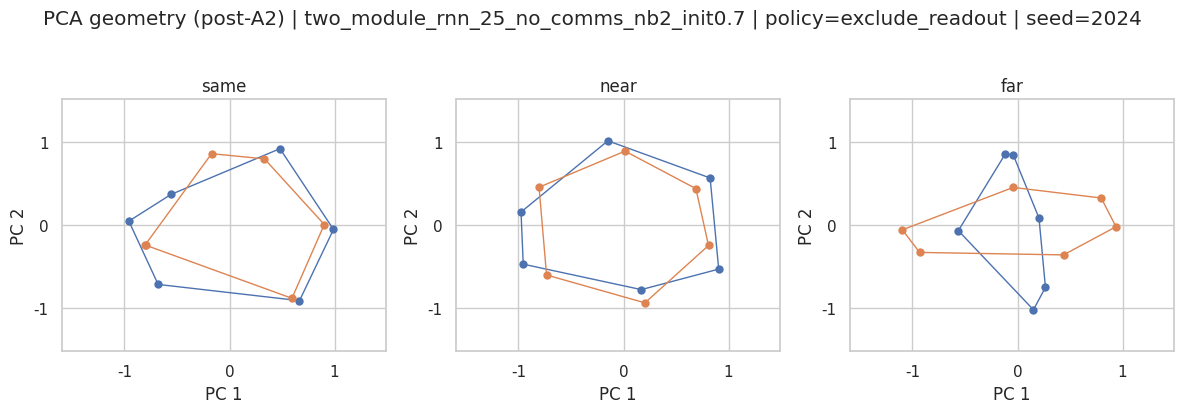

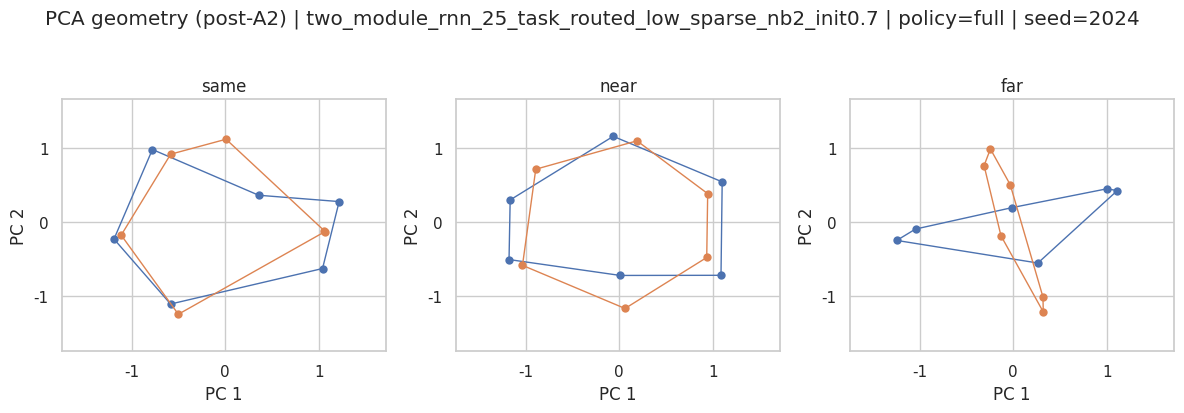

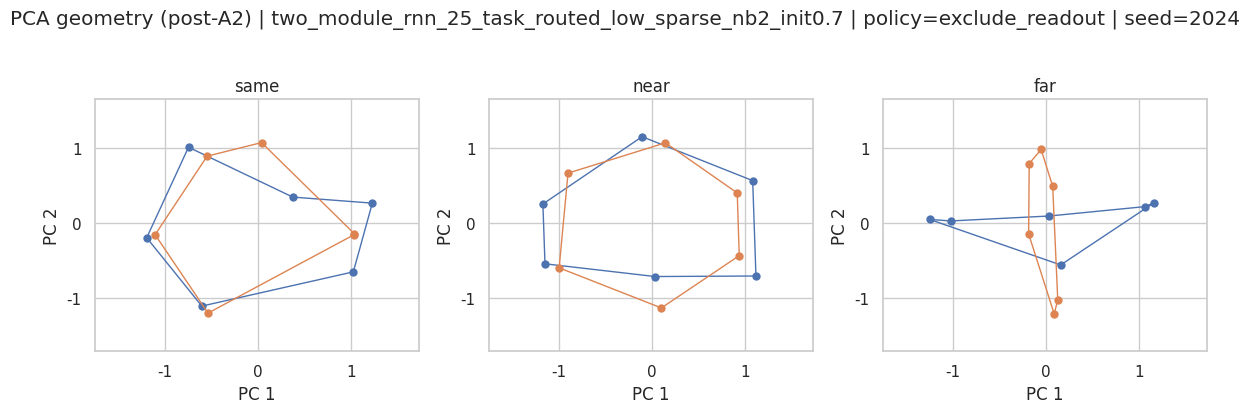

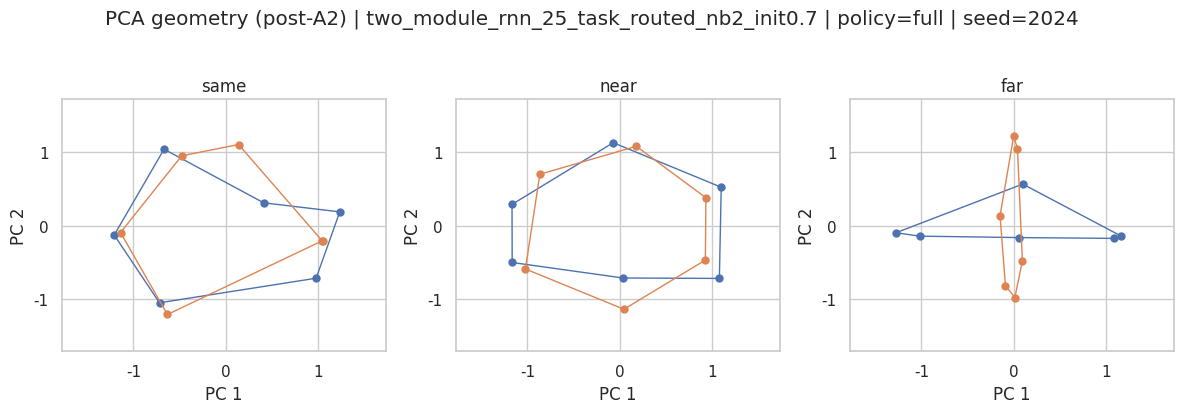

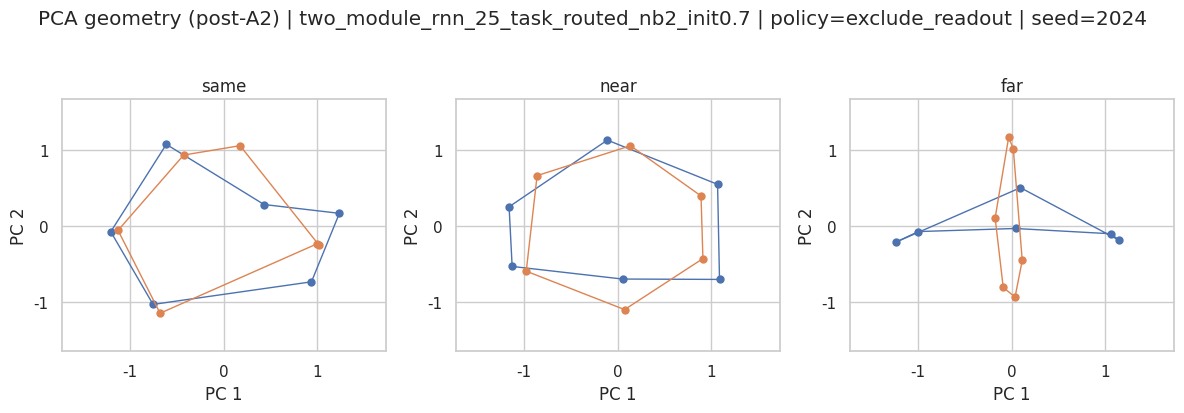

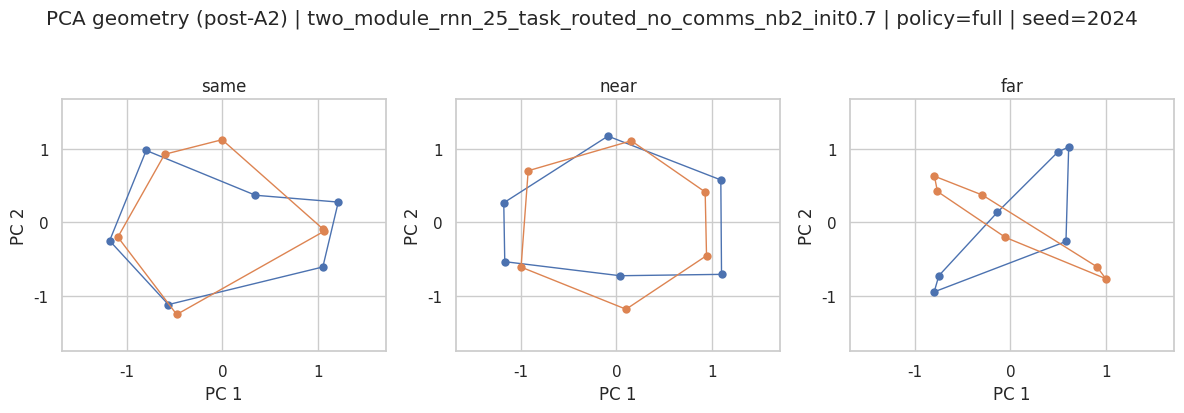

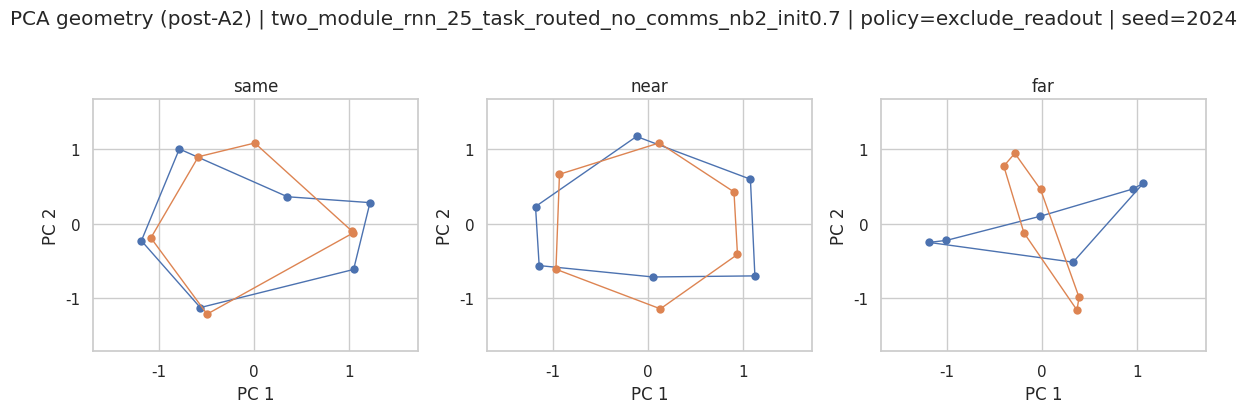

In [20]:
# PCA geometry in the same style as the Holton-style init-scale notebooks.
# For each (condition_name, policy), show same/near/far in a 1x3 panel using plot_split_stim.

import re
from a1b2.utils.figure_utils import plot_split_stim, get_axis_limits

phase_idx = 2
n_stim_plot = 12
task_colours = ["#4C72B0", "#DD8452"]


def _condition_from_participant_name(participant_name: str) -> str:
    if "_same_" in participant_name:
        return "same"
    if "_near_" in participant_name:
        return "near"
    if "_far_" in participant_name:
        return "far"
    return "unknown"


def _first_pca2_for_schedule(run_dir: Path, schedule: str, phase_idx: int, n_stim_plot: int):
    for sim_file in sorted(run_dir.glob("sim_*.npz")):
        participant = sim_file.stem.replace("sim_", "")
        if _condition_from_participant_name(participant) != schedule:
            continue
        with np.load(sim_file, allow_pickle=True) as data:
            key = f"hiddens_post_phase_{phase_idx}"
            if key not in data:
                continue
            hids = np.asarray(data[key])
            if hids.ndim > 2:
                hids = hids.reshape(hids.shape[0], -1)
            if hids.shape[0] < n_stim_plot or hids.shape[1] < 2:
                continue
            X = hids[:n_stim_plot]
            return PCA(n_components=2).fit_transform(X)
    return None


if not SMOKE_ROOT.exists():
    print("Smoke folder not found:", SMOKE_ROOT)
else:
    run_rows = []
    for run_dir in sorted(SMOKE_ROOT.iterdir()):
        if not run_dir.is_dir():
            continue
        m = re.match(r"(.+)__policy-(.+)__seed-(\d+)$", run_dir.name)
        if m is None:
            continue
        run_rows.append(
            {
                "run_dir": run_dir,
                "condition_name": m.group(1),
                "policy": m.group(2),
                "seed": int(m.group(3)),
            }
        )

    run_meta = pd.DataFrame(run_rows)
    print("Geometry runs:", run_meta.shape[0])

    if run_meta.empty:
        print("No run folders matched expected naming pattern.")
    else:
        for condition_name in sorted(run_meta["condition_name"].unique()):
            for policy in ["full", "exclude_readout"]:
                sub = run_meta[(run_meta["condition_name"] == condition_name) & (run_meta["policy"] == policy)]
                if sub.empty:
                    continue

                # Use the first available seed for a concise Holton-style panel.
                row = sub.sort_values("seed").iloc[0]
                run_dir = row["run_dir"]
                seed = int(row["seed"])

                all_2d = []
                for sched in ["same", "near", "far"]:
                    all_2d.append(_first_pca2_for_schedule(run_dir, sched, phase_idx, n_stim_plot))

                valid = [x for x in all_2d if x is not None]
                if not valid:
                    print(f"No valid PCA geometry for {condition_name} | {policy} | seed={seed}")
                    continue

                lims_global = get_axis_limits(np.vstack(valid))
                fig, axes = plt.subplots(1, 3, figsize=(12, 4))

                for ax, sched, X2 in zip(axes, ["same", "near", "far"], all_2d):
                    if X2 is None:
                        ax.set_title(f"{sched} (no data)")
                        ax.axis("off")
                        continue
                    plot_split_stim(ax, X2, task_colours, lims_global)
                    ax.set_title(sched)

                fig.suptitle(
                    f"PCA geometry (post-A2) | {condition_name} | policy={policy} | seed={seed}",
                    y=1.03,
                )
                plt.tight_layout()
                plt.show()

In [21]:
# Exhaustive numeric summary tables for interpretation
# Includes transfer/interference, policy deltas, and representation summaries.

import numpy as np

if transfer_df.empty:
    print("transfer_df is empty. Run the experiment cell first.")
else:
    t = transfer_df.copy()
    # Keep both sign conventions explicit:
    # - error_diff = initial_B_acc - final_A1_acc (more negative => stronger interference)
    # - interference_mag = final_A1_acc - initial_B_acc (positive magnitude)
    t["interference_mag"] = t["final_A1_acc"] - t["initial_B_acc"]

    transfer_summary = (
        t.groupby(["condition_name", "policy"], as_index=False)
        .agg(
            n=("error_diff", "count"),
            error_diff_mean=("error_diff", "mean"),
            error_diff_median=("error_diff", "median"),
            error_diff_std=("error_diff", "std"),
            error_diff_sem=("error_diff", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan),
            final_A1_acc_mean=("final_A1_acc", "mean"),
            initial_B_acc_mean=("initial_B_acc", "mean"),
            interference_mag_mean=("interference_mag", "mean"),
            interference_mag_median=("interference_mag", "median"),
        )
        .sort_values(["condition_name", "policy"])
    )

    # Policy delta table: exclude_readout - full
    td = transfer_summary.pivot(index="condition_name", columns="policy", values=[
        "error_diff_mean", "interference_mag_mean", "final_A1_acc_mean", "initial_B_acc_mean"
    ])
    td.columns = [f"{a}__{b}" for a, b in td.columns]
    for col in ["error_diff_mean", "interference_mag_mean", "final_A1_acc_mean", "initial_B_acc_mean"]:
        if f"{col}__exclude_readout" in td.columns and f"{col}__full" in td.columns:
            td[f"delta_excl_minus_full__{col}"] = td[f"{col}__exclude_readout"] - td[f"{col}__full"]
    transfer_delta = td.reset_index()

    display(transfer_summary)
    display(transfer_delta)

if rep_df.empty:
    print("rep_df is empty. Run the experiment cell first.")
else:
    r = rep_df.copy()
    rep_summary = (
        r.groupby(["condition_name", "phase", "policy"], as_index=False)
        .agg(
            n=("n_pcs_95", "count"),
            n_pcs95_mean=("n_pcs_95", "mean"),
            n_pcs95_median=("n_pcs_95", "median"),
            n_pcs95_std=("n_pcs_95", "std"),
            n_pcs95_sem=("n_pcs_95", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan),
            n_pcs95_min=("n_pcs_95", "min"),
            n_pcs95_max=("n_pcs_95", "max"),
        )
        .sort_values(["condition_name", "phase", "policy"])
    )

    rd = rep_summary.pivot(index=["condition_name", "phase"], columns="policy", values="n_pcs95_mean")
    rd = rd.rename(columns={c: f"n_pcs95_mean__{c}" for c in rd.columns})
    if "n_pcs95_mean__exclude_readout" in rd.columns and "n_pcs95_mean__full" in rd.columns:
        rd["delta_excl_minus_full__n_pcs95_mean"] = rd["n_pcs95_mean__exclude_readout"] - rd["n_pcs95_mean__full"]
    rep_delta = rd.reset_index()

    display(rep_summary)
    display(rep_delta)

# Optional: single compact merged view at condition level
if (not transfer_df.empty) and (not rep_df.empty):
    rep_cond = rep_df.groupby(["condition_name", "policy"], as_index=False)["n_pcs_95"].mean().rename(columns={"n_pcs_95": "n_pcs95_overall_mean"})
    merged = transfer_summary.merge(rep_cond, on=["condition_name", "policy"], how="left")
    display(merged.sort_values(["condition_name", "policy"]))

,condition_name,policy,n,error_diff_mean,error_diff_median,error_diff_std,error_diff_sem,final_A1_acc_mean,initial_B_acc_mean,interference_mag_mean,interference_mag_median
0,two_module_rnn_25_low_sparse_nb2_init0.7,exclude_readout,6,-0.531470,-0.537294,0.169563,0.069224,0.976108,0.444638,0.531470,0.537294
1,two_module_rnn_25_low_sparse_nb2_init0.7,full,6,-0.506455,-0.512904,0.171409,0.069977,0.978634,0.472179,0.506455,0.512904
2,two_module_rnn_25_nb2_init0.7,exclude_readout,6,-0.520159,-0.528780,0.175637,0.071703,0.976821,0.456662,0.520159,0.528780
3,two_module_rnn_25_nb2_init0.7,full,6,-0.491694,-0.512141,0.177720,0.072554,0.980926,0.489232,0.491694,0.512141
4,two_module_rnn_25_no_comms_nb2_init0.7,exclude_readout,6,-0.533854,-0.538074,0.173424,0.070800,0.975349,0.441495,0.533854,0.538074
5,two_module_rnn_25_no_comms_nb2_init0.7,full,6,-0.510889,-0.512707,0.174451,0.071220,0.977498,0.466609,0.510889,0.512707
6,two_module_rnn_25_task_routed_low_sparse_nb2_i...,exclude_readout,6,-0.407127,-0.444724,0.107191,0.043761,0.842169,0.435043,0.407127,0.444724
7,two_module_rnn_25_task_routed_low_sparse_nb2_i...,full,6,-0.392111,-0.431600,0.117031,0.047778,0.831451,0.439339,0.392111,0.431600
8,two_module_rnn_25_task_routed_nb2_init0.7,exclude_readout,6,-0.407475,-0.447125,0.101826,0.041570,0.842261,0.434787,0.407475,0.447125
9,two_module_rnn_25_task_routed_nb2_init0.7,full,6,-0.393278,-0.426377,0.114170,0.046610,0.832121,0.438843,0.393278,0.426377


,condition_name,error_diff_mean__exclude_readout,error_diff_mean__full,interference_mag_mean__exclude_readout,interference_mag_mean__full,final_A1_acc_mean__exclude_readout,final_A1_acc_mean__full,initial_B_acc_mean__exclude_readout,initial_B_acc_mean__full,delta_excl_minus_full__error_diff_mean,delta_excl_minus_full__interference_mag_mean,delta_excl_minus_full__final_A1_acc_mean,delta_excl_minus_full__initial_B_acc_mean
0,two_module_rnn_25_low_sparse_nb2_init0.7,-0.531470,-0.506455,0.531470,0.506455,0.976108,0.978634,0.444638,0.472179,-0.025015,0.025015,-0.002526,-0.027541
1,two_module_rnn_25_nb2_init0.7,-0.520159,-0.491694,0.520159,0.491694,0.976821,0.980926,0.456662,0.489232,-0.028465,0.028465,-0.004104,-0.032569
2,two_module_rnn_25_no_comms_nb2_init0.7,-0.533854,-0.510889,0.533854,0.510889,0.975349,0.977498,0.441495,0.466609,-0.022965,0.022965,-0.002149,-0.025114
3,two_module_rnn_25_task_routed_low_sparse_nb2_i...,-0.407127,-0.392111,0.407127,0.392111,0.842169,0.831451,0.435043,0.439339,-0.015016,0.015016,0.010719,-0.004297
4,two_module_rnn_25_task_routed_nb2_init0.7,-0.407475,-0.393278,0.407475,0.393278,0.842261,0.832121,0.434787,0.438843,-0.014197,0.014197,0.010140,-0.004057
5,two_module_rnn_25_task_routed_no_comms_nb2_ini...,-0.406896,-0.391935,0.406896,0.391935,0.842037,0.831572,0.435141,0.439637,-0.014961,0.014961,0.010465,-0.004496


,condition_name,phase,policy,n,n_pcs95_mean,n_pcs95_median,n_pcs95_std,n_pcs95_sem,n_pcs95_min,n_pcs95_max
0,two_module_rnn_25_low_sparse_nb2_init0.7,post_A,exclude_readout,6,8.666667,9.0,0.516398,0.210819,8.0,9.0
1,two_module_rnn_25_low_sparse_nb2_init0.7,post_A,full,6,8.666667,9.0,0.516398,0.210819,8.0,9.0
2,two_module_rnn_25_low_sparse_nb2_init0.7,post_A2,exclude_readout,6,7.666667,8.0,0.516398,0.210819,7.0,8.0
3,two_module_rnn_25_low_sparse_nb2_init0.7,post_A2,full,6,7.666667,8.0,0.516398,0.210819,7.0,8.0
4,two_module_rnn_25_low_sparse_nb2_init0.7,post_B,exclude_readout,6,7.333333,7.0,0.516398,0.210819,7.0,8.0
5,two_module_rnn_25_low_sparse_nb2_init0.7,post_B,full,6,7.333333,7.0,0.516398,0.210819,7.0,8.0
6,two_module_rnn_25_nb2_init0.7,post_A,exclude_readout,6,8.666667,9.0,0.516398,0.210819,8.0,9.0
7,two_module_rnn_25_nb2_init0.7,post_A,full,6,8.333333,8.0,0.516398,0.210819,8.0,9.0
8,two_module_rnn_25_nb2_init0.7,post_A2,exclude_readout,6,7.500000,7.5,0.547723,0.223607,7.0,8.0
9,two_module_rnn_25_nb2_init0.7,post_A2,full,6,7.500000,7.5,0.547723,0.223607,7.0,8.0


policy,condition_name,phase,n_pcs95_mean__exclude_readout,n_pcs95_mean__full,delta_excl_minus_full__n_pcs95_mean
0,two_module_rnn_25_low_sparse_nb2_init0.7,post_A,8.666667,8.666667,0.000000
1,two_module_rnn_25_low_sparse_nb2_init0.7,post_A2,7.666667,7.666667,0.000000
2,two_module_rnn_25_low_sparse_nb2_init0.7,post_B,7.333333,7.333333,0.000000
3,two_module_rnn_25_nb2_init0.7,post_A,8.666667,8.333333,0.333333
4,two_module_rnn_25_nb2_init0.7,post_A2,7.500000,7.500000,0.000000
5,two_module_rnn_25_nb2_init0.7,post_B,7.333333,7.333333,0.000000
6,two_module_rnn_25_no_comms_nb2_init0.7,post_A,8.833333,8.833333,0.000000
7,two_module_rnn_25_no_comms_nb2_init0.7,post_A2,7.666667,7.666667,0.000000
8,two_module_rnn_25_no_comms_nb2_init0.7,post_B,7.500000,7.333333,0.166667
9,two_module_rnn_25_task_routed_low_sparse_nb2_i...,post_A,8.166667,8.166667,0.000000


,condition_name,policy,n,error_diff_mean,error_diff_median,error_diff_std,error_diff_sem,final_A1_acc_mean,initial_B_acc_mean,interference_mag_mean,interference_mag_median,n_pcs95_overall_mean
0,two_module_rnn_25_low_sparse_nb2_init0.7,exclude_readout,6,-0.531470,-0.537294,0.169563,0.069224,0.976108,0.444638,0.531470,0.537294,7.888889
1,two_module_rnn_25_low_sparse_nb2_init0.7,full,6,-0.506455,-0.512904,0.171409,0.069977,0.978634,0.472179,0.506455,0.512904,7.888889
2,two_module_rnn_25_nb2_init0.7,exclude_readout,6,-0.520159,-0.528780,0.175637,0.071703,0.976821,0.456662,0.520159,0.528780,7.833333
3,two_module_rnn_25_nb2_init0.7,full,6,-0.491694,-0.512141,0.177720,0.072554,0.980926,0.489232,0.491694,0.512141,7.722222
4,two_module_rnn_25_no_comms_nb2_init0.7,exclude_readout,6,-0.533854,-0.538074,0.173424,0.070800,0.975349,0.441495,0.533854,0.538074,8.000000
5,two_module_rnn_25_no_comms_nb2_init0.7,full,6,-0.510889,-0.512707,0.174451,0.071220,0.977498,0.466609,0.510889,0.512707,7.944444
6,two_module_rnn_25_task_routed_low_sparse_nb2_i...,exclude_readout,6,-0.407127,-0.444724,0.107191,0.043761,0.842169,0.435043,0.407127,0.444724,7.388889
7,two_module_rnn_25_task_routed_low_sparse_nb2_i...,full,6,-0.392111,-0.431600,0.117031,0.047778,0.831451,0.439339,0.392111,0.431600,7.444444
8,two_module_rnn_25_task_routed_nb2_init0.7,exclude_readout,6,-0.407475,-0.447125,0.101826,0.041570,0.842261,0.434787,0.407475,0.447125,7.500000
9,two_module_rnn_25_task_routed_nb2_init0.7,full,6,-0.393278,-0.426377,0.114170,0.046610,0.832121,0.438843,0.393278,0.426377,7.500000
